<a href="https://colab.research.google.com/github/Chaitanya15-ai/OIBSIP/blob/main/ChaitanyaSawant_Task4(Level2__Unveiling_the_Android_App_Market_Analyzing_Google_Play_Store_Data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                     App                                  Translated_Review  \
0  10 Best Foods for You  I like eat delicious food. That's I'm cooking ...   
1  10 Best Foods for You    This help eating healthy exercise regular basis   
2  10 Best Foods for You                                                NaN   
3  10 Best Foods for You         Works great especially going grocery store   
4  10 Best Foods for You                                       Best idea us   

  Sentiment  Sentiment_Polarity  Sentiment_Subjectivity  
0  Positive                1.00                0.533333  
1  Positive                0.25                0.288462  
2       NaN                 NaN                     NaN  
3  Positive                0.40                0.875000  
4  Positive                1.00                0.300000  
(64295, 5)
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype:

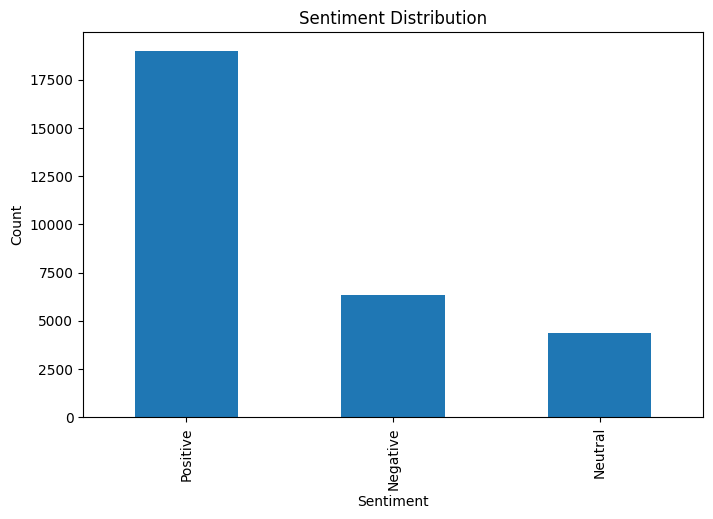

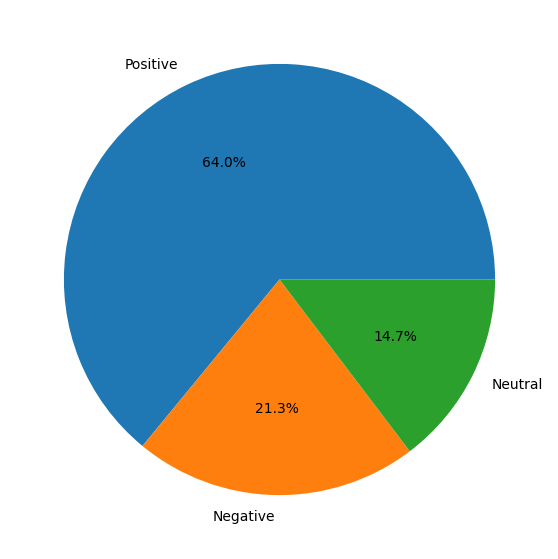

App
Facebook                          130
Episode - Choose Your Story       124
Angry Birds Classic               107
Family Locator - GPS Tracker      105
Google Photos                     101
8fit Workouts & Meal Planner      100
Calorie Counter - Macros          100
Calorie Counter - MyFitnessPal     99
ColorNote Notepad Notes            99
Adobe Acrobat Reader               98
Name: count, dtype: int64


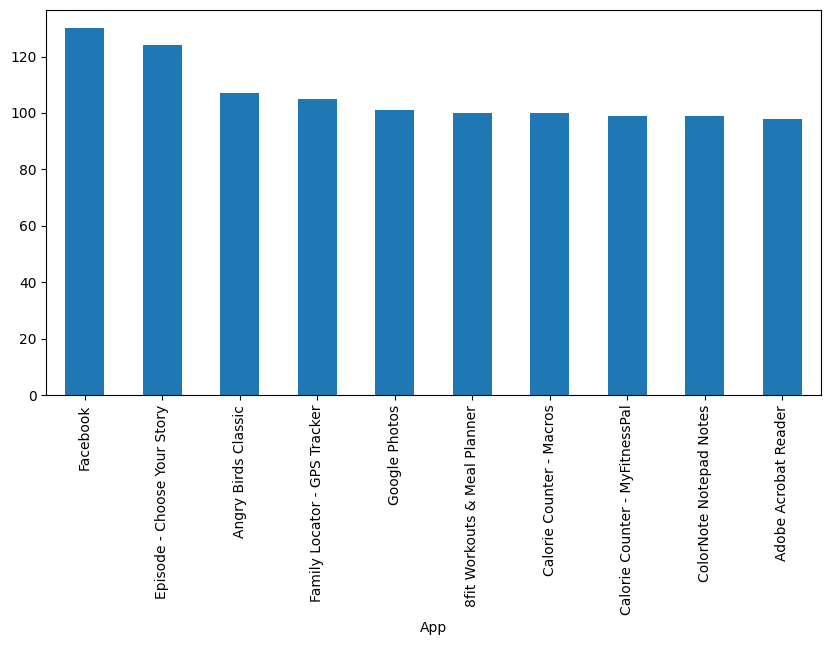

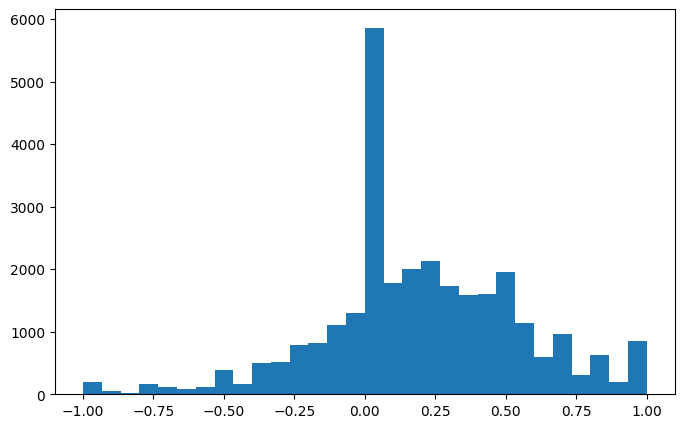

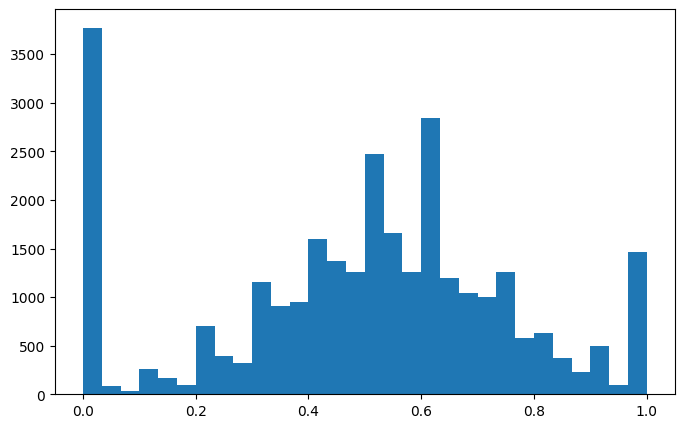

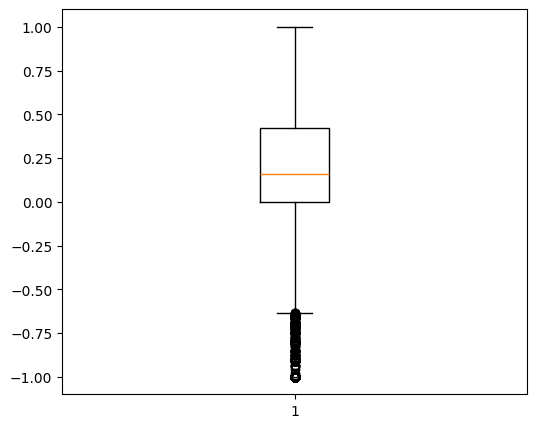

count    29692.000000
mean       106.895224
std        102.600246
min          2.000000
25%         30.000000
50%         79.000000
75%        153.000000
max       2713.000000
Name: Review_Length, dtype: float64


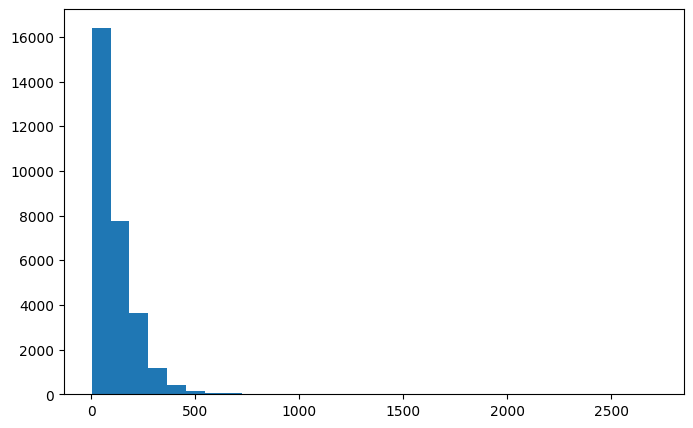

[('I', 24419), ('game', 4549), ('like', 3752), ('The', 3532), ('It', 3317), ('get', 3314), ('This', 3017), ('good', 2650), ('love', 2480), ('time', 2421), ('would', 2181), ("It's", 2071), ('app.', 2065), ('really', 1969), ('great', 1902), ('even', 1864), ("I'm", 1752), ("can't", 1639), ('it.', 1621), ('make', 1459)]
App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.650000
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64
App
Dra

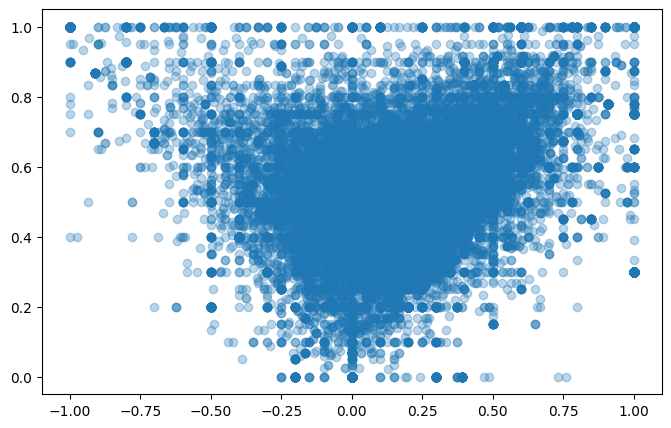

Completed


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("/content/user_reviews.csv")

print(df.head())

print(df.shape)

print(df.isnull().sum())

df = df.drop_duplicates()

df = df.dropna(
subset=['Translated_Review']
)

print(df.shape)

print(df.info())

print(df.describe())

sentiment_count = df[
'Sentiment'
].value_counts()

print(sentiment_count)

plt.figure(figsize=(8,5))

sentiment_count.plot(
kind='bar'
)

plt.title(
"Sentiment Distribution"
)

plt.xlabel(
"Sentiment"
)

plt.ylabel(
"Count"
)

plt.show()

plt.figure(figsize=(7,7))

sentiment_count.plot(
kind='pie',
autopct='%1.1f%%'
)

plt.ylabel("")

plt.show()

top_apps = df[
'App'
].value_counts().head(10)

print(top_apps)

plt.figure(figsize=(10,5))

top_apps.plot(
kind='bar'
)

plt.show()

plt.figure(figsize=(8,5))

plt.hist(

df[
'Sentiment_Polarity'
].dropna(),

bins=30

)

plt.show()

plt.figure(figsize=(8,5))

plt.hist(

df[
'Sentiment_Subjectivity'
].dropna(),

bins=30

)

plt.show()

plt.figure(figsize=(6,5))

plt.boxplot(

df[
'Sentiment_Polarity'
].dropna()

)

plt.show()

df[
'Review_Length'
] = df[
'Translated_Review'
].astype(str).apply(len)

print(

df[
'Review_Length'
].describe()

)

plt.figure(figsize=(8,5))

plt.hist(

df[
'Review_Length'
],

bins=30

)

plt.show()

text = " ".join(

df[
'Translated_Review'
].astype(str)

)

words = text.split()

counter = Counter(words)

print(

counter.most_common(20)

)

app_sentiment = df.groupby(

'App'

)[

'Sentiment_Polarity'

].mean()

print(

app_sentiment.sort_values(
ascending=False
).head(10)

)

print(

app_sentiment.sort_values(
ascending=True
).head(10)

)

corr = df[
[
'Sentiment_Polarity',
'Sentiment_Subjectivity',
'Review_Length'
]
].corr()

print(corr)

plt.figure(figsize=(8,5))

plt.scatter(

df[
'Sentiment_Polarity'
],

df[
'Sentiment_Subjectivity'
],

alpha=.3

)

plt.show()

df.to_csv(

"cleaned_reviews.csv",

index=False

)

print("Completed")